## Лаборатона робота №3

**Виконали:**
- Сачек Вледислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

**Хід роботи:**
1. Завантажити початковi данi.
2. Представити данi графiчно.
3. Iнiцiалiзувати параметри: швидкiсть навчання, кiлькiсть епох (=100) i додатково, якщо задано згiдно з варiантом, кiлькiсть пакетiв i/або параметр регуляризацiї.
4. Iнiцiалiзувати вектор параметрiв.
5. Реалiзувати функцiю, яка задає модель, наприклад:
• лiнiйну регресiю,
• полiномiальну регресiю,
• iншу криву, яку пiдiбрати вiдповiдно до заданих даних.
6. Задати функцiю втрат (одну згiдно з варiантом):
• MSE,
• MSE з регуляризацiєю за нормами L1 або L2.
7. Задати операцiю, яка буде викликатися на кожнiй iтерацiї алгоритма
навчання:
• алгоритм стохастичного градiєнтного спуску,
• алгоритм мiнi-пакетного градiєнтного спуску,
• алгоритм стохастичного градiєнтного спуску з моментом,
• алгоритм Adagrad,
• алгоритм Adadelta,
• алгоритм Adam.
8. Виконати навчання моделi.
9. Виводити значення функцiї втрат через кожнi 10 епох.
10. Зберегти контрольнi точки через регулярнi iнтервали пiд час навчання. В кiнцi навчання зберегти результуючу модель. Вiдновити останню контрольну точку при запуску,якщо навчання було перервано.
11. Налаштувати гiперпараметр швидкiсть навчання i додатково, якщо задано згiдно варiанту, розмiр мiнi-пакета. Подивитися на форму кривої навчання.
12. Дослiдити рiзнi значення параметра регуляризацiї i пiдiбрати найкраще з них, якщо згiдно з варiантом задано регуляризовану функцiю втрат. В цьому випадку данi мають бути попередньо розбитi на навчальний та перевiрочний набори.
13. Побудувати графiк з початковими даними та лiнiєю регресiї.

**Варіант 2**

Полiномiальна регресiя, алгоритм градiєнтного спуску за мiнi-батчами, MSE з регуляризацiєю за нормою L2.

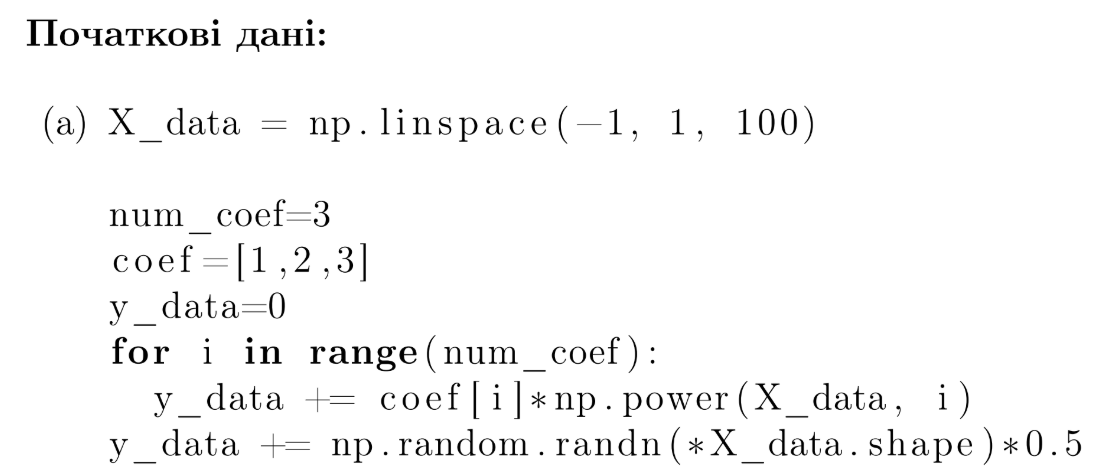

### Генерація даних
Дані генеруються за формулою поліному другого степеня:

**y = 1 + 2x + 3x² + ε**, де ε ~ N(0, 0.5)

Точок: 100, рівномірно на відрізку [-1, 1].

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

X_data = np.linspace(-1, 1, 100)

num_coef = 3
coef = [1, 2, 3]

y_data = 0
for i in range(num_coef):
    y_data += coef[i] * np.power(X_data, i)

y_data += np.random.randn(*X_data.shape) * 0.5

print("Розмір X:", X_data.shape)
print("Розмір y:", y_data.shape)
print("Перші 5 значень X:", X_data[:5].round(3))
print("Перші 5 значень y:", y_data[:5].round(3))

Розмір X: (100,)
Розмір y: (100,)
Перші 5 значень X: [-1.    -0.98  -0.96  -0.939 -0.919]
Перші 5 значень y: [2.071 2.964 2.402 1.911 1.16 ]


### Візуалізація даних

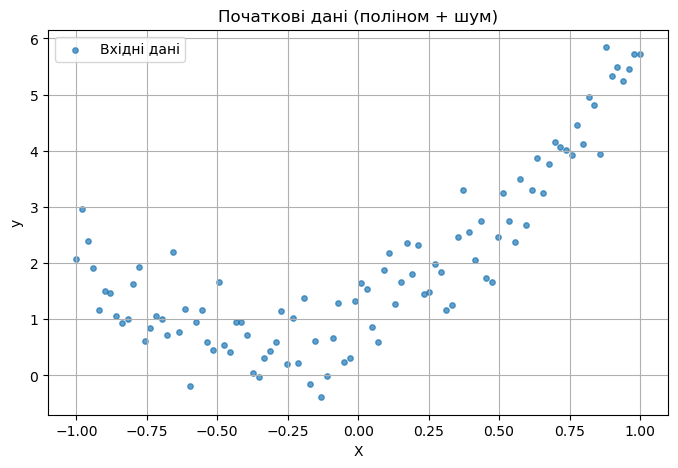

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, s=15, alpha=0.7, label="Вхідні дані")
plt.title("Початкові дані (поліном + шум)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

На графіку видно характерну форму параболи із шумом.
У лівій частині (-1 .. 0) значення y низькі та розкидані,
у правій (0.5 .. 1) — швидко зростають до 5–6.
Це відповідає очікуваній поведінці поліному 1 + 2x + 3x².

### Гіперпараметри

In [3]:
learning_rate = 0.01   # швидкість навчання
epochs        = 100    # кількість епох
batch_size    = 20     # розмір міні-батча (100 / 20 = 5 батчів)
lambda_l2     = 0.001  # параметр L2-регуляризації

### Ініціалізація вектора параметрів та Dataset

Вектор параметрів θ = [w₀, w₁, w₂] розміром (3, 1) ініціалізується
нулями як `tf.Variable` — це навчувані параметри моделі.

`tf.data.Dataset` формується з оригінального вектора X (не розширеного),
перемішується та розбивається на батчі по 20 зразків → 5 батчів на епоху.

In [4]:
# Конвертуємо у тензори
X_tensor = tf.cast(X_data, tf.float32)
y_tensor = tf.cast(y_data, tf.float32)

# Крок 4: ініціалізація вектора параметрів
theta = tf.Variable(tf.zeros([3, 1], dtype=tf.float32), name="theta")
print("Початкові θ:", theta.numpy().flatten())

# Dataset з оригінальним X (не розширеним)
dataset = tf.data.Dataset.from_tensor_slices((X_tensor, y_tensor))
dataset = dataset.shuffle(buffer_size=100, seed=42).batch(batch_size)

print(f"Кількість батчів: {len(list(dataset))}")

Початкові θ: [0. 0. 0.]
Кількість батчів: 5


### Клас моделі

Клас `PolynomialModel` наслідує `tf.keras.Model`.

Метод `call()` виконує два кроки:
1. Будує матрицю ознак всередині моделі: [1, x, x²] → форма (batch, 3)
2. Обчислює передбачення: ŷ = X_poly @ θ, після чого застосовує
   `tf.squeeze` для приведення форми з (batch, 1) до (batch,) —
   що відповідає формі y і дозволяє коректно обчислити MSE у наступній частині.

In [5]:
class PolynomialModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # theta ініціалізується тут же (посилання на змінну з Блоку 4)
        self.theta = theta

    def call(self, x):
        # Будуємо матрицю ознак [1, x, x²] всередині моделі
        X_poly = tf.stack([
            tf.ones_like(x),
            x,
            x ** 2
        ], axis=1)                          # (batch, 3)
        y_pred = tf.matmul(X_poly, self.theta)  # (batch, 1)
        return tf.squeeze(y_pred, axis=1)       # (batch,) — виправлено!


model = PolynomialModel()

# Перевірка
for X_batch, y_batch in dataset.take(1):
    y_pred = model(X_batch)
    print("Форма батча X     :", X_batch.shape)
    print("Форма батча y     :", y_batch.shape)
    print("Форма передбачення:", y_pred.shape)   # має бути (20,) як y
    print("Початкові θ       :", model.theta.numpy().flatten())

Форма батча X     : (20,)
Форма батча y     : (20,)
Форма передбачення: (20,)
Початкові θ       : [0. 0. 0.]
